In [1]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_exploded = df.explode('job_skills').copy()

In [3]:
median_count_skill = df_exploded.groupby(['job_title_short','job_skills'])['salary_year_avg'].agg(['median', 'size'])
median_count_skill = median_count_skill.sort_values(by='size', ascending=False)
median_count_skill = median_count_skill.loc['Data Analyst'].head(10)
median_count_skill

,median,size
job_skills,,
sql,92500.0,92428
excel,84479.0,66860
python,98500.0,57190
tableau,95000.0,46455
power bi,90000.0,39380
r,92527.5,29996
sas,90000.0,27998
powerpoint,85000.0,13822
word,80000.0,13562


In [4]:
df_exploded1 = df[df['job_title_short'] == 'Data Analyst'].copy()
df_exploded1 = df_exploded1.explode('job_skills')

In [5]:
skill_counts = df_exploded1.groupby('job_skills').agg(median_salary=('salary_year_avg','median'), skill_count=('job_skills','size'))
skill_counts = skill_counts.sort_values(by='skill_count', ascending=False).head(10)
skill_counts

,median_salary,skill_count
job_skills,,
sql,92500.0,92428
excel,84479.0,66860
python,98500.0,57190
tableau,95000.0,46455
power bi,90000.0,39380
r,92527.5,29996
sas,90000.0,27998
powerpoint,85000.0,13822
word,80000.0,13562


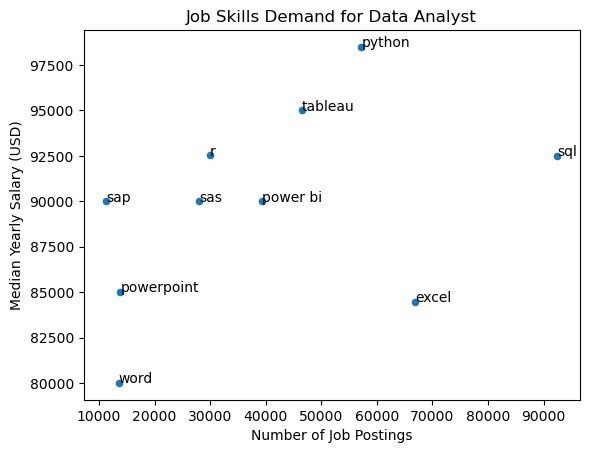

In [9]:
skill_counts.plot(x='skill_count', y='median_salary', kind='scatter')
plt.title('Job Skills Demand for Data Analyst')
plt.ylabel('Median Yearly Salary (USD)')
plt.xlabel('Number of Job Postings')
for i,skill in enumerate(skill_counts.index):
    plt.text(skill_counts['skill_count'].iloc[i], skill_counts['median_salary'].iloc[i], skill)